In [1]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

np.random.seed(42)

2026-06-13 18:50:18.379654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781376618.544036      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781376618.589328      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df=pd.read_csv('/kaggle/input/teen-phone-addiction-and-lifestyle-survey/teen_phone_addiction_dataset.csv')

df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


In [3]:
df=df.drop(columns=['Name','Location','ID','Gender','School_Grade','Phone_Usage_Purpose'])
df

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,4.0,6.1,78,5,0.1,10,3,8,0,1.4,86,19,3.6,1.7,1.2,4,8.7,10.0
1,17,5.5,6.5,70,5,0.0,3,7,3,0,0.9,96,9,1.1,4.0,1.8,2,5.3,10.0
2,13,5.8,5.5,93,8,0.8,2,3,10,0,0.5,137,8,0.3,1.5,0.4,6,5.7,9.2
3,18,3.1,3.9,78,8,1.6,9,10,3,0,1.4,128,7,3.1,1.6,0.8,8,3.0,9.8
4,14,2.5,6.7,56,4,1.1,1,5,1,0,1.0,96,20,2.6,0.9,1.1,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,3.9,6.4,53,4,0.9,7,10,2,1,0.3,80,15,2.7,1.8,1.0,8,9.4,9.8
2996,13,3.6,7.3,93,5,0.0,8,8,9,1,0.9,45,8,3.1,0.0,0.3,9,5.2,5.5
2997,14,3.2,6.5,98,1,0.0,4,3,9,0,0.2,51,13,2.4,0.2,2.4,9,5.9,6.2
2998,17,6.7,7.5,67,3,0.2,3,5,9,0,1.6,125,17,1.7,2.6,1.5,4,6.1,10.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3000 non-null   int64  
 1   Daily_Usage_Hours       3000 non-null   float64
 2   Sleep_Hours             3000 non-null   float64
 3   Academic_Performance    3000 non-null   int64  
 4   Social_Interactions     3000 non-null   int64  
 5   Exercise_Hours          3000 non-null   float64
 6   Anxiety_Level           3000 non-null   int64  
 7   Depression_Level        3000 non-null   int64  
 8   Self_Esteem             3000 non-null   int64  
 9   Parental_Control        3000 non-null   int64  
 10  Screen_Time_Before_Bed  3000 non-null   float64
 11  Phone_Checks_Per_Day    3000 non-null   int64  
 12  Apps_Used_Daily         3000 non-null   int64  
 13  Time_on_Social_Media    3000 non-null   float64
 14  Time_on_Gaming          3000 non-null   

In [5]:
df.describe()

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [6]:
#df['School_Grade']=df['School_Grade'].str.extract('(\d+)',expand=False).astype(int)

In [7]:
'''from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Phone_Usage_Purpose']=le.fit_transform(df['Phone_Usage_Purpose'])
df'''


"from sklearn.preprocessing import LabelEncoder\nle=LabelEncoder()\ndf['Gender']=le.fit_transform(df['Gender'])\ndf['Phone_Usage_Purpose']=le.fit_transform(df['Phone_Usage_Purpose'])\ndf"

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3000 non-null   int64  
 1   Daily_Usage_Hours       3000 non-null   float64
 2   Sleep_Hours             3000 non-null   float64
 3   Academic_Performance    3000 non-null   int64  
 4   Social_Interactions     3000 non-null   int64  
 5   Exercise_Hours          3000 non-null   float64
 6   Anxiety_Level           3000 non-null   int64  
 7   Depression_Level        3000 non-null   int64  
 8   Self_Esteem             3000 non-null   int64  
 9   Parental_Control        3000 non-null   int64  
 10  Screen_Time_Before_Bed  3000 non-null   float64
 11  Phone_Checks_Per_Day    3000 non-null   int64  
 12  Apps_Used_Daily         3000 non-null   int64  
 13  Time_on_Social_Media    3000 non-null   float64
 14  Time_on_Gaming          3000 non-null   

In [9]:
df.columns

Index(['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level'],
      dtype='object')

In [10]:
scaler=MinMaxScaler()
df[['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']] = scaler.fit_transform(
    df[['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']]
)
#Min Max scaler to make inputs easier for model to read
df

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,0.000000,0.347826,0.442857,0.56,0.5,0.025,1.000000,0.222222,0.777778,0.0,0.538462,0.507692,0.933333,0.72,0.425,0.400000,0.333333,0.621429,1.000000
1,0.666667,0.478261,0.500000,0.40,0.5,0.000,0.222222,0.666667,0.222222,0.0,0.346154,0.584615,0.266667,0.22,1.000,0.600000,0.111111,0.378571,1.000000
2,0.000000,0.504348,0.357143,0.86,0.8,0.200,0.111111,0.222222,1.000000,0.0,0.192308,0.900000,0.200000,0.06,0.375,0.133333,0.555556,0.407143,0.911111
3,0.833333,0.269565,0.128571,0.56,0.8,0.400,0.888889,1.000000,0.222222,0.0,0.538462,0.830769,0.133333,0.62,0.400,0.266667,0.777778,0.214286,0.977778
4,0.166667,0.217391,0.528571,0.12,0.4,0.275,0.000000,0.444444,0.000000,0.0,0.384615,0.584615,1.000000,0.52,0.225,0.366667,1.000000,0.264286,0.844444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.500000,0.339130,0.485714,0.06,0.4,0.225,0.666667,1.000000,0.111111,1.0,0.115385,0.461538,0.666667,0.54,0.450,0.333333,0.777778,0.671429,0.977778
2996,0.000000,0.313043,0.614286,0.86,0.5,0.000,0.777778,0.777778,0.888889,1.0,0.346154,0.192308,0.200000,0.62,0.000,0.100000,0.888889,0.371429,0.500000
2997,0.166667,0.278261,0.500000,0.96,0.1,0.000,0.333333,0.222222,0.888889,0.0,0.076923,0.238462,0.533333,0.48,0.050,0.800000,0.888889,0.421429,0.577778
2998,0.666667,0.582609,0.642857,0.34,0.3,0.050,0.222222,0.444444,0.888889,0.0,0.615385,0.807692,0.800000,0.34,0.650,0.500000,0.333333,0.435714,1.000000


In [11]:
corr=df.corr()
corr_target=corr[['Addiction_Level']]
corr_target

,Addiction_Level
Age,0.031306
Daily_Usage_Hours,0.600771
Sleep_Hours,-0.216681
Academic_Performance,0.012264
Social_Interactions,-0.010631
Exercise_Hours,-0.021015
Anxiety_Level,0.016005
Depression_Level,0.008491
Self_Esteem,-0.022292
Parental_Control,-0.001016


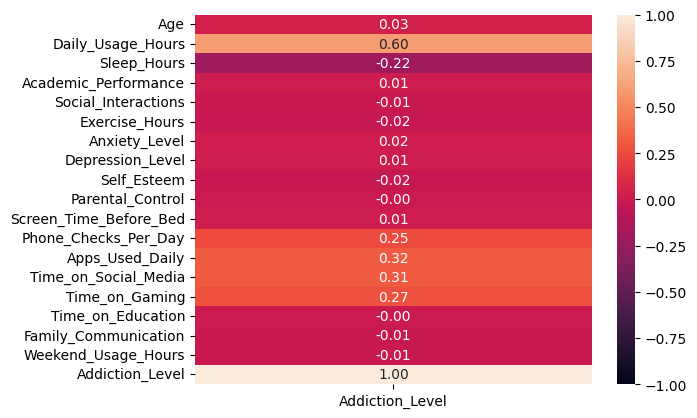

In [12]:
sns.heatmap(corr_target,fmt='.2f',vmin=-1, vmax=1,annot=True)
plt.show()

In [13]:
df=df.drop(axis=1,labels=['Age','Academic_Performance','Social_Interactions','Exercise_Hours','Anxiety_Level','Depression_Level','Self_Esteem','Parental_Control','Screen_Time_Before_Bed','Time_on_Education','Family_Communication','Weekend_Usage_Hours'])

In [14]:
df

,Daily_Usage_Hours,Sleep_Hours,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Addiction_Level
0,0.347826,0.442857,0.507692,0.933333,0.72,0.425,1.000000
1,0.478261,0.500000,0.584615,0.266667,0.22,1.000,1.000000
2,0.504348,0.357143,0.900000,0.200000,0.06,0.375,0.911111
3,0.269565,0.128571,0.830769,0.133333,0.62,0.400,0.977778
4,0.217391,0.528571,0.584615,1.000000,0.52,0.225,0.844444
...,...,...,...,...,...,...,...
2995,0.339130,0.485714,0.461538,0.666667,0.54,0.450,0.977778
2996,0.313043,0.614286,0.192308,0.200000,0.62,0.000,0.500000
2997,0.278261,0.500000,0.238462,0.533333,0.48,0.050,0.577778
2998,0.582609,0.642857,0.807692,0.800000,0.34,0.650,1.000000


<Axes: >

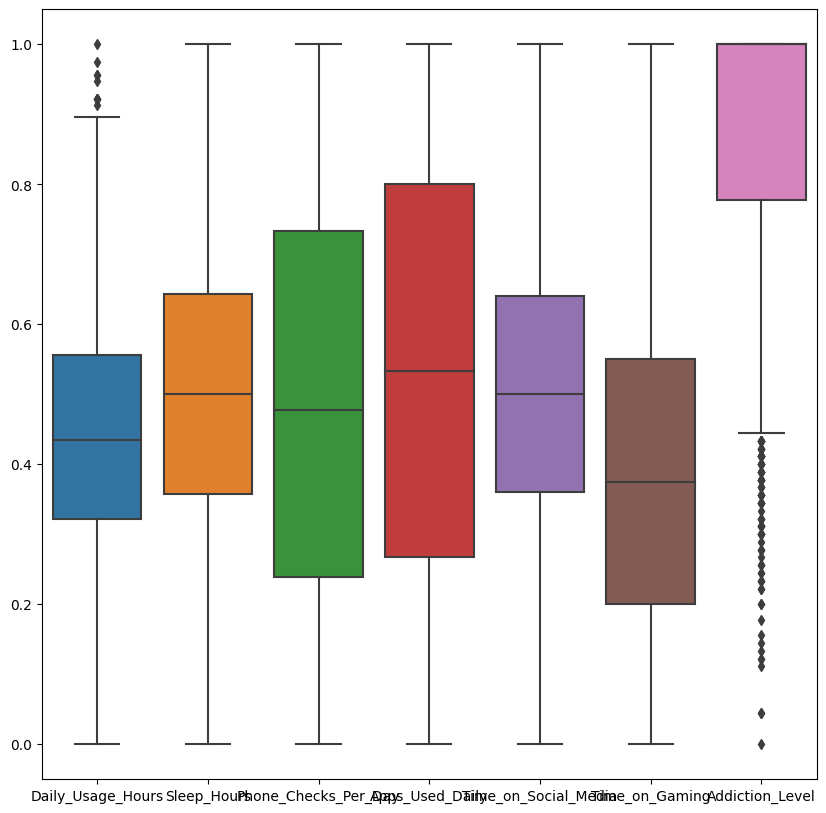

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.boxplot(df)

In [16]:
x=df.drop(columns='Addiction_Level')
x

,Daily_Usage_Hours,Sleep_Hours,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming
0,0.347826,0.442857,0.507692,0.933333,0.72,0.425
1,0.478261,0.500000,0.584615,0.266667,0.22,1.000
2,0.504348,0.357143,0.900000,0.200000,0.06,0.375
3,0.269565,0.128571,0.830769,0.133333,0.62,0.400
4,0.217391,0.528571,0.584615,1.000000,0.52,0.225
...,...,...,...,...,...,...
2995,0.339130,0.485714,0.461538,0.666667,0.54,0.450
2996,0.313043,0.614286,0.192308,0.200000,0.62,0.000
2997,0.278261,0.500000,0.238462,0.533333,0.48,0.050
2998,0.582609,0.642857,0.807692,0.800000,0.34,0.650


In [17]:
y=df['Addiction_Level']
y

0       1.000000
1       1.000000
2       0.911111
3       0.977778
4       0.844444
          ...   
2995    0.977778
2996    0.500000
2997    0.577778
2998    1.000000
2999    0.588889
Name: Addiction_Level, Length: 3000, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [20]:
model = Sequential([
    Dense(1, activation='sigmoid'), # Logistic regression

])

In [21]:
from tensorflow.keras.optimizers import Adam
opt=Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['mae','mse'])
history= model.fit(x_train,y_train,epochs=120,batch_size=50,validation_data=(x_test,y_test))

Epoch 1/120


I0000 00:00:1781376633.785858      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1781376634.782724      63 service.cc:148] XLA service 0x7d3aec0187e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781376634.783038      63 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781376635.023962      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7379 - mae: 0.4059 - mse: 0.1932

I0000 00:00:1781376635.455175      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.7369 - mae: 0.4055 - mse: 0.1928 - val_loss: 0.6799 - val_mae: 0.3767 - val_mse: 0.1657
Epoch 2/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6667 - mae: 0.3650 - mse: 0.1590 - val_loss: 0.6180 - val_mae: 0.3388 - val_mse: 0.1358
Epoch 3/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6076 - mae: 0.3348 - mse: 0.1339 - val_loss: 0.5662 - val_mae: 0.3044 - val_mse: 0.1110
Epoch 4/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5583 - mae: 0.2982 - mse: 0.1074 - val_loss: 0.5239 - val_mae: 0.2744 - val_mse: 0.0912
Epoch 5/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5168 - mae: 0.2691 - mse: 0.0885 - val_loss: 0.4889 - val_mae: 0.2483 - val_mse: 0.0754
Epoch 6/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4857 - mae: 0.2490 - mse: 0.0756 - val_loss: 0.4604 - val_mae: 0.2260 - val_mse: 0.0630
Epoch 7/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4620 - mae: 0.2238 - mse: 0.0621 - val_loss: 0.4370 - va

In [22]:
mse=history.history['mse']
loss=history.history['loss']
mae=history.history['mae']
val_loss=history.history['val_loss']
epochs=range(1,121)

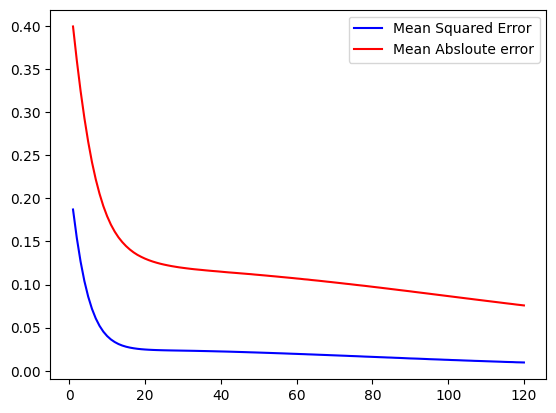

In [23]:
plt.plot(epochs , mse , color = 'b',) #blue show test accuracy
plt.plot(epochs , mae,  color = 'r') #red color shows validataion acc
plt.legend(['Mean Squared Error', 'Mean Absloute error'])
plt.show()

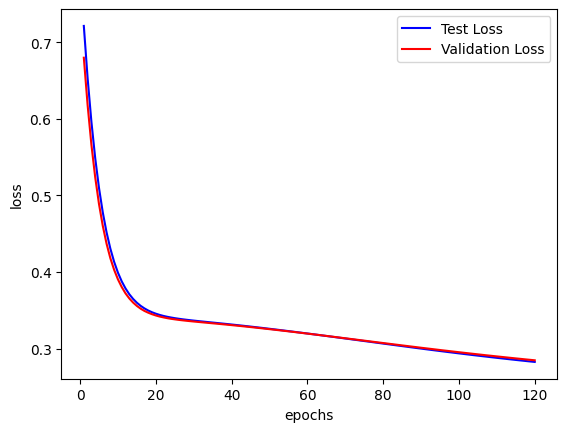

In [24]:
plt.plot(epochs , loss , color = 'b')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(epochs , val_loss,  color = 'r')
plt.legend(['Test Loss', 'Validation Loss'])
plt.show()

In [25]:
model.evaluate(x_test, y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2917 - mae: 0.0745 - mse: 0.0091


[0.2847118377685547, 0.07457765936851501, 0.009224863722920418]

In [26]:
test_loss, test_mae, test_mse = model.evaluate(x_test, y_test)
print(f"Test MAE: {test_mae:.4f}, Test MSE: {test_mse:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2917 - mae: 0.0745 - mse: 0.0091 
Test MAE: 0.0746, Test MSE: 0.0092


In [27]:
df.columns

Index(['Daily_Usage_Hours', 'Sleep_Hours', 'Phone_Checks_Per_Day',
       'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming',
       'Addiction_Level'],
      dtype='object')

In [28]:

import joblib

scaler = MinMaxScaler()
scaler.fit(x_train)  # or fit on your full dataset

# Save the scaler
joblib.dump(scaler, '/kaggle/working/scaler.pkl')

['/kaggle/working/scaler.pkl']

In [29]:
model.save('addiction_model.h5')